## 1. Imports 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.manifold import TSNE
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import umap.umap_ as umap, hdbscan

## 2. Excel loading

In [28]:
RAW_FILE, SHEET = "ESB_v8.xlsx", "1. District-level data"
MISSING_DATA    = {"Missing value","Blank cell","TBD","N/A","NA",""," "}

df = (pd.read_excel(RAW_FILE, sheet_name=SHEET)
        .replace(list(MISSING_DATA), np.nan))
print(f"✓ fichier lu : {df.shape}")


✓ fichier lu : (19516, 91)


## 3. Make sure columns are <= 2 words long + rebrand column names

In [29]:
def slugify(col, n_words=2):
    col = col.strip()
    m   = re.match(r"(?P<code>\d+[a-z])\.\s*(?P<rest>.+)", col, flags=re.I)
    code = (m["code"] + "_") if m else ""
    rest = m["rest"] if m else col
    base = "_".join(re.sub(r"[^0-9a-zA-Z ]", " ", rest)
                    .split()[:n_words]).lower()
    return code + base

new_cols = pd.Series(df.columns).apply(slugify)

seen = {}
for i, c in enumerate(new_cols):
    seen[c] = seen.get(c, 0) + 1
    new_cols[i] = f"{c}_{seen[c]}" if seen[c] > 1 else c
df.columns = new_cols

## 4. yes/no → Int8 booleans

In [ ]:
yn_cols = [
    c for c in df.columns
    if df[c].dropna().isin({"yes", "no", "Yes", "No"}).all() # check if all values are yes/no
]
df[yn_cols] = df[yn_cols].apply(
    lambda s: s.str.lower().map({"yes": 1, "no": 0}).astype("Int8") # convert to 1/0
)

print("✓ yes/no convertis :", len(yn_cols), "colonnes")

✓ yes/no convertis : 8 colonnes


## 4. Convert columns to numerical variables using coerce

In [33]:
def try_numeric(s):
    ratio_numeric = pd.to_numeric(s, errors="coerce").notna().mean()
    if ratio_numeric > 0.95:
        return pd.to_numeric(s, errors="coerce")
    else:
        return s

df = df.apply(try_numeric)
print("✓ conversion numérique")

✓ conversion numérique


## 5. Variables selection based on scenarios

In [35]:
# slugs réels (vérifiés dans df.columns)
AXIS_COLS      = ["3a_number_of","3f_number_of","3i_percent_of"]
ECO_COLS      = ["5d_percent_low", "5n_qualified_for", "5o_epa_2022", "5p_epa_2023"]
DIVERSITY_COLS = ["5b_percent_non"]

BASE_VARS      = AXIS_COLS + ECO_COLS + DIVERSITY_COLS
PASS1_VARS = BASE_VARS + ["4f_median_household","4u_percent_hispanic"]
PASS2_VARS = PASS1_VARS + ["4g_percent_poverty","4e_percent_free",
                           "4j_percent_black","4n_percent_asian"]
print("✓ listes prêtes")

✓ listes prêtes


## 6. Common pipeline for each scenario

Silhouette t-SNE k=6 : 0.561


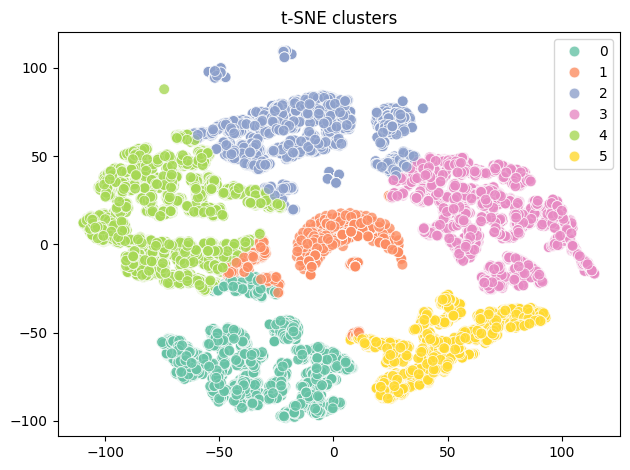

c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


TypeError: __init__() got an unexpected keyword argument 'random_state'

In [ ]:
# ----- 1. Use a variable set and rename columns -------------------
feat = df[BASE_VARS].copy()          # ← replace with PASS1_VARS or PASS2_VARS
feat.rename(columns={
    "3a_number_of":"num_esb_committed",
    "3f_number_of":"num_esb_operating",
    "3i_percent_of":"pct_esb_operating",
    "5b_percent_non":"pct_nonwhite",
    "5d_percent_low":"pct_lowinc",
    "5n_qualified_for":"rescue_plan",
    "5o_epa_2022":"epa_2022",
    "5p_epa_2023":"epa_2023",
}, inplace=True)

# ----- 2. Preprocessing ---------------------------------------------------
num_cols = feat.select_dtypes("number").columns
preproc = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("yj" , PowerTransformer("yeo-johnson", standardize=False)),
        ("sc" , RobustScaler())]), num_cols)])
X = preproc.fit_transform(feat)

# ----- 3. t-SNE ---------------------------------------------------------
emb = TSNE(2, perplexity=30, init="pca",
           learning_rate="auto", random_state=42).fit_transform(X)

# ----- 4. K-Medoids k=6 -------------------------------------------------
kmed = KMedoids(6, metric="manhattan",
                init="k-medoids++", random_state=42).fit(emb)
sil  = silhouette_score(emb, kmed.labels_, metric="manhattan")
print(f"Silhouette t-SNE k=6 : {sil:.3f}")

# ----- 5. Plot t-SNE ----------------------------------------------------
sns.scatterplot(x=emb[:,0], y=emb[:,1], hue=kmed.labels_,
                palette="Set2", s=60, alpha=.8)
plt.title("ft-SNE clusters on BASE_VARS")
plt.tight_layout()
plt.show()


In [42]:
profiles = pd.DataFrame({
    "num_esb_committed": feat["num_esb_committed"],
    "num_esb_operating": feat["num_esb_operating"],
    "pct_esb_operating": feat["pct_esb_operating"],
    "pct_nonwhite": feat["pct_nonwhite"],
    "pct_lowinc": feat["pct_lowinc"],
    "rescue_plan": feat["rescue_plan"],
    "epa_2022": feat["epa_2022"],
    "epa_2023": feat["epa_2023"],
    "cluster": kmed.labels_
})
profiles = profiles.groupby("cluster").mean().reset_index()
display(profiles.head(15))


,cluster,num_esb_committed,num_esb_operating,pct_esb_operating,pct_nonwhite,pct_lowinc,rescue_plan,epa_2022,epa_2023
0,0,0.290139,0.095052,0.015746,0.121095,0.272051,0.040228,0.899252,0.0
1,1,0.019135,0.003544,0.000851,0.131513,0.306286,0.003012,0.007619,0.007619
2,2,1.668306,0.595221,0.031096,0.379366,0.276882,0.137386,0.216796,0.216796
3,3,1.530619,0.243943,0.037966,0.423698,0.409124,0.06965,0.839166,0.998991
4,4,0.430104,0.130551,0.012601,0.164518,0.165979,0.029508,0.0,0.000298
5,5,0.270370,0.079365,0.016147,0.078345,0.312208,0.064021,1.0,1.0


- 6 profils de districts identifiés par t-SNE (k-medoids, silhouette = 0.56) :
    - **Cluster 0** : Diversité modérée (12 % non-white), revenus médian-faibles (27 % low-inc), adoption ESB modérée, subventions très ciblées (90 % EPA 2022), districts “priorisés EPA” encore au stade pilote.
    - **Cluster 1** : Profil social proche du 0 mais quasi aucune aide, adoption ESB quasi nulle, 0 % EPA/ARP, “angle mort” sans électrification ni soutien.
    - **Cluster 2** : Forte diversité (38 % non-white), revenus moyens, champions de l’adoption ESB (1.67 committés / 0.59 en service), aides modérées (EPA ≈ 22 %, ARP 14 %), districts moteurs alliant équité et climat.
    - **Cluster 3** : Plus pauvres & plus diversifiés (42 % non-white, 41 % low-inc), très engagés (1.53 / 0.24), taux d’opération le plus haut, 84 % EPA 2022 + ARP 7 %, “vitrine équité” grâce au soutien public.
    - **Cluster 4** : Diversité moyenne (16 %), revenus confortables (17 % low-inc), adopteurs intermédiaires, peu d’aides, districts aisés progressant sans subvention.
    - **Cluster 5** : Faible diversité (8 %), low-inc élevé (31 %), engagement timide, faible taux d’aides, zones rurales avec obstacles logistiques et budgétaires.

- Carte : gradient “équité → richesse” de gauche (clusters 3 & 2) à droite (4 & 5).
- Deux pôles d’excellence :  
    - Cluster 2 = gros volumes + mix social  
    - Cluster 3 = priorités sociales + aides massives
- Cluster 1 = angle mort : très peu d’ESB, aucun soutien.


c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP silhouette : 0.601


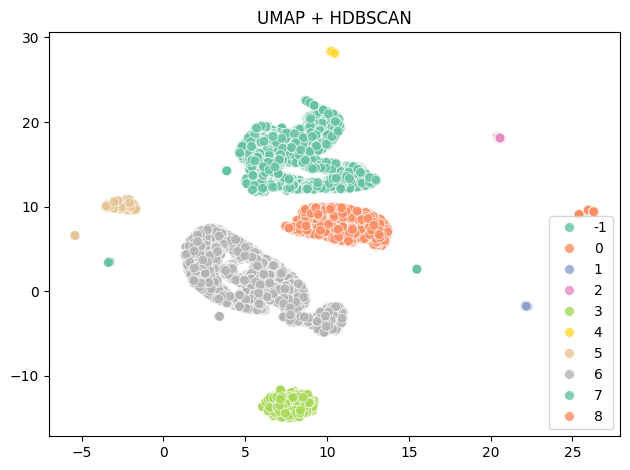

In [ ]:
# ----- 6. UMAP + HDBSCAN -----------------------------------
um = umap.UMAP(n_neighbors=25, min_dist=0.05,
               metric="manhattan", random_state=42).fit_transform(X)
hdb = hdbscan.HDBSCAN(min_cluster_size=60, metric="manhattan").fit(um)
mask = hdb.labels_!=-1
if mask.any():
    silU = silhouette_score(um[mask], hdb.labels_[mask], metric="manhattan")
    print("UMAP silhouette :", round(silU,3))
sns.scatterplot(x=um[:,0], y=um[:,1], hue=hdb.labels_,
                palette="Set2", s=50, alpha=.8)
plt.title("UMAP + HDBSCAN")
plt.tight_layout()
plt.show()

## 7. Profile for each clustering scenario

In [38]:
feat["cluster"] = kmed.labels_ 
profile = (feat.groupby("cluster")[num_cols]
           .agg(["median","mean"])
           .T.round(2))
display(profile.head(15))

cluster                          0         1         2         3         4  \
num_esb_committed median       0.0       0.0       0.0       0.0       0.0   
                  mean    0.290139  0.019135  1.668306  1.530619  0.430104   
num_esb_operating median       0.0       0.0       0.0       0.0       0.0   
                  mean    0.095052  0.003544  0.595221  0.243943  0.130551   
pct_esb_operating median       0.0       0.0       0.0       0.0       0.0   
                  mean    0.015746  0.000851  0.031096  0.037966  0.012601   
pct_lowinc        median   0.27385  0.306082  0.272347  0.398456  0.161508   
                  mean    0.272051  0.306286  0.276882  0.409124  0.165979   
rescue_plan       median       0.0       0.0       0.0       0.0       0.0   
                  mean    0.040228  0.003012  0.137386   0.06965  0.029508   
epa_2022          median       1.0       0.0       0.0       1.0       0.0   
                  mean    0.899252  0.007619  0.216796  0.839166       0.0   
epa_2023          median       0.0       0.0       0.0       1.0       0.0   
                  mean         0.0  0.007619  0.216796  0.998991  0.000298   
pct_nonwhite      median  0.075339  0.100156  0.327776  0.373718   0.12769   

cluster                          5  
num_esb_committed median       0.0  
                  mean     0.27037  
num_esb_operating median       0.0  
                  mean    0.079365  
pct_esb_operating median       0.0  
                  mean    0.016147  
pct_lowinc        median  0.304264  
                  mean    0.312208  
rescue_plan       median       0.0  
                  mean    0.064021  
epa_2022          median       1.0  
                  mean         1.0  
epa_2023          median       1.0  
                  mean         1.0  
pct_nonwhite      median  0.069049

### Synthèse UMAP + HDBSCAN

- **Correspondance forte** entre les clusters UMAP+HDBSCAN et les clusters t-SNE/k-medoids : robustesse méthodologique confirmée.
- **Six grands groupes identifiés** :
    - **0 (orange)** : Grands adopteurs, volumes élevés, aides EPA/ARP modérées.
    - **2 (vert foncé)** : Districts “équité”, diversité forte, priorisés EPA, mise en service rapide.
    - **6 (gris clair)** : Plusieurs commandes mais mise en service lente, besoin d’assistance opérationnelle.
    - **5 (ocre)** : Districts aisés, transition auto-financée.
    - **8 (rose)** : Early adopters, forte mise en service, bons retours d’expérience, à mobiliser comme mentors.
    - **3, 4, 7, 9** : Micro-poches spécifiques (rural isolé, faible diversité, etc.), analyses ciblées possibles.
- **Bruit (-1)** : 29 points isolés, à auditer (qualité de saisie ou cas locaux particuliers).
- **Forme “galet” centrale (label 6)** : Bloc dense d’adopteurs modérés, stratégie d’accompagnement collective envisageable.
- **Actions recommandées** :
    - Accélérer la mise en service : assistance technique/logistique (labels 2 et 6).
    - Capitaliser sur les leaders : partage d’expérience, webinaires (labels 0 et 8).
    - Simplifier le financement : mini-guichet pour micro-groupes (labels 3/4/7).
    - Vérification des données : audit des points bruit (-1).
